In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for item in os.listdir('/content/drive/MyDrive'):
    print(item)

Classroom
Saved from Chrome
Untitled document.gdoc
Colab Notebooks
Untitled presentation.gslides
IITG dataset


In [3]:
import os

DATASET_PATH = "/content/drive/MyDrive/IITG dataset"

print("Contents of IITG dataset:")
for item in os.listdir(DATASET_PATH):
    print(item)

Contents of IITG dataset:
cleaned_dataset


In [4]:
CLEANED_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"

print("Contents of cleaned_dataset:")
for item in os.listdir(CLEANED_PATH):
    print(item)

Contents of cleaned_dataset:
metadata.csv
data
extra_infos
processed_dataset_v1


In [5]:

DATA_PATH = os.path.join(CLEANED_PATH, "data")
METADATA_PATH = os.path.join(CLEANED_PATH, "metadata.csv")

csv_files = [
    f for f in os.listdir(DATA_PATH)
    if f.lower().endswith(".csv")
]

print("Number of CSV files:", len(csv_files))
print("Metadata file exists:", os.path.exists(METADATA_PATH))

print("\nSample CSV files:")
for f in csv_files[:10]:
    print(f)

Number of CSV files: 7600
Metadata file exists: True

Sample CSV files:
06664.csv
06548.csv
06547.csv
06608.csv
06576.csv
06668.csv
06461.csv
06525.csv
06432.csv
06580.csv


In [6]:
# Inspect one data file and metadata

import pandas as pd

sample_file = os.path.join(DATA_PATH, csv_files[0])
sample_df = pd.read_csv(sample_file)

print("Sample file:", csv_files[0])
print("Rows:", sample_df.shape[0])
print("Columns:", sample_df.shape[1])

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
display(sample_df.head())

print("\nMetadata:")
metadata = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

display(metadata.head())

Sample file: 06664.csv
Rows: 1403
Columns: 6

Columns:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']

First 5 rows:


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.515781,-0.000839,33.942370,0.000,-0.007,0.000
1,3.194762,-3.612513,33.866384,-3.629,1.461,2.453
2,3.578757,1.515107,33.857983,1.507,4.289,9.422
3,3.635699,1.515922,33.863405,1.507,4.359,16.187
4,3.665379,1.515677,33.799425,1.507,4.392,22.937



Metadata:
Metadata shape: (7565, 10)
Metadata columns: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [7]:
# Data quality checks

total_missing = 0
total_duplicates = 0
invalid_files = []

for file in csv_files:
    path = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(path)

        total_missing += df.isna().sum().sum()
        total_duplicates += df.duplicated().sum()

    except Exception as e:
        invalid_files.append((file, str(e)))

print("Total missing values:", total_missing)
print("Total duplicate rows:", total_duplicates)
print("Unreadable/invalid CSV files:", len(invalid_files))

if invalid_files:
    print("\nInvalid files:")
    for file, error in invalid_files[:10]:
        print(file, ":", error)

Total missing values: 18465
Total duplicate rows: 0
Unreadable/invalid CSV files: 0


In [8]:
# First-look statistics

print("Sample data statistics:")
display(sample_df.describe(include="all"))

Sample data statistics:


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
count,1403.000000,1403.000000,1403.000000,1403.000000,1403.000000,1403.00000
mean,4.160758,0.507932,26.002153,0.504004,4.111653,4935.42518
std,0.093199,0.592150,2.423471,0.589210,1.164246,2891.25812
min,3.194762,-3.612513,23.720182,-3.629000,-0.007000,0.00000
25%,4.185156,0.057132,23.928740,0.055000,4.235000,2404.32750
50%,4.197537,0.194272,24.769278,0.189000,4.300000,4929.98400
75%,4.199716,0.958130,28.454643,0.951500,4.592000,7445.03850
max,4.203718,1.521529,33.942370,1.507000,4.926000,9930.26500


In [9]:
# Day 7 - Target/Class Coverage and Obvious Inconsistencies

print("Metadata columns:")
print(metadata.columns.tolist())

# Find possible target/class columns
target_cols = [
    col for col in metadata.columns
    if any(word in col.lower()
           for word in ["class", "target", "label", "fault", "status", "type"])
]

print("\nPossible target/class columns:")
print(target_cols)

# Check target/class distribution
for col in target_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", metadata[col].nunique(dropna=False))
    print(metadata[col].value_counts(dropna=False))

# Check missing values in target/class columns
print("\nMissing values in target/class columns:")
for col in target_cols:
    print(col, ":", metadata[col].isna().sum())

Metadata columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

Possible target/class columns:
['type']

--- type ---
Unique values: 3
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Missing values in target/class columns:
type : 0


Columns visualized:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']


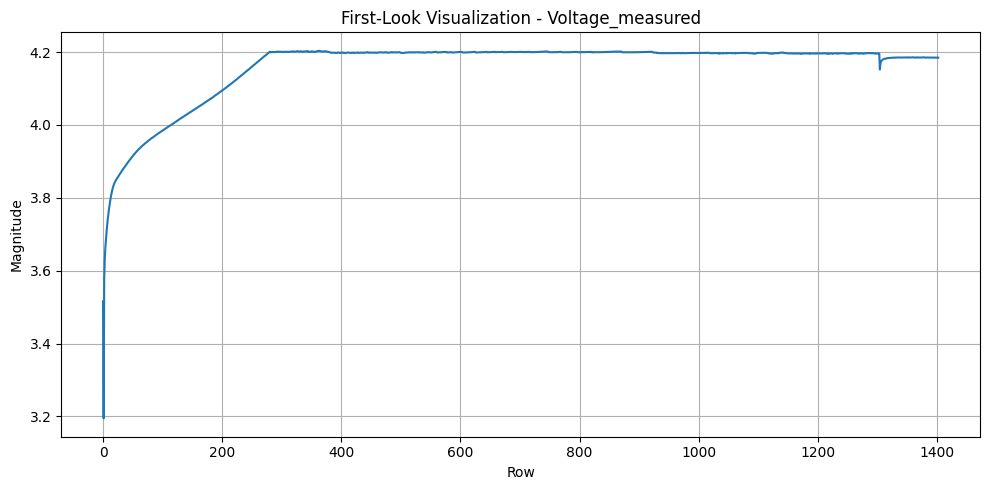

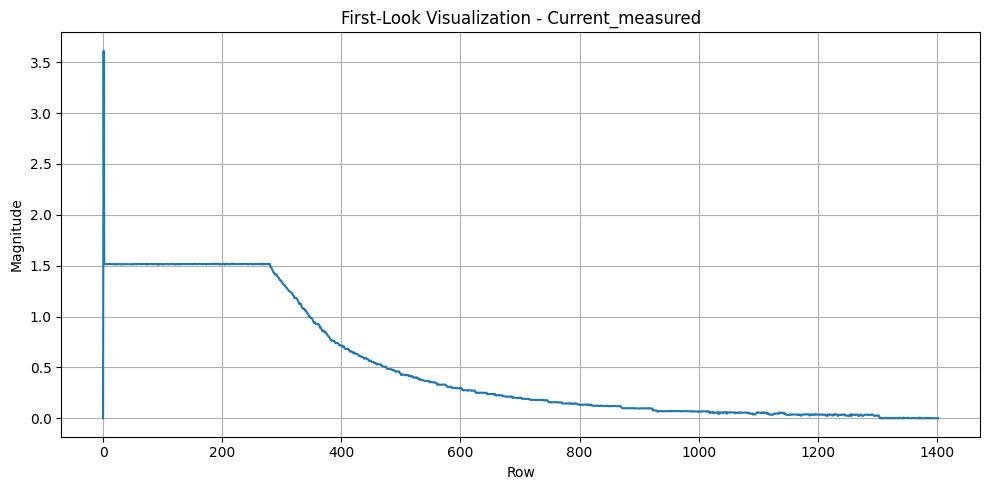

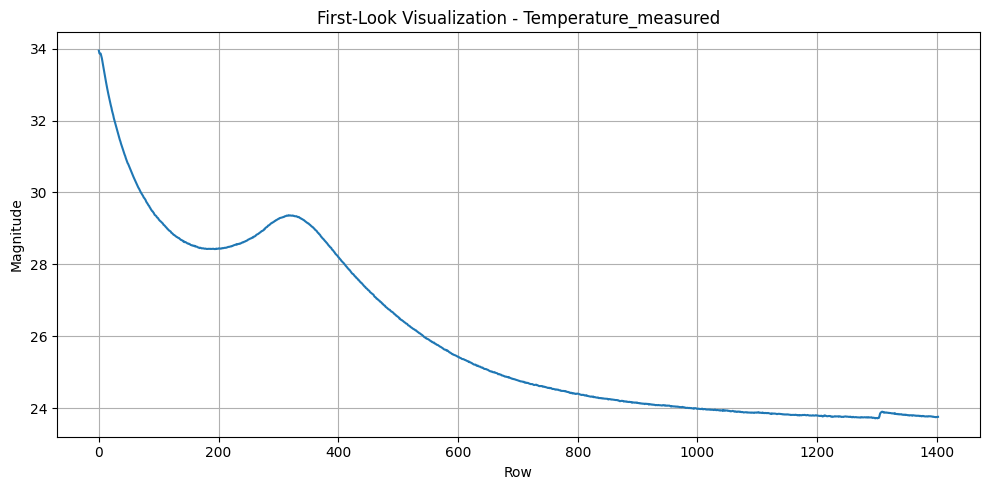

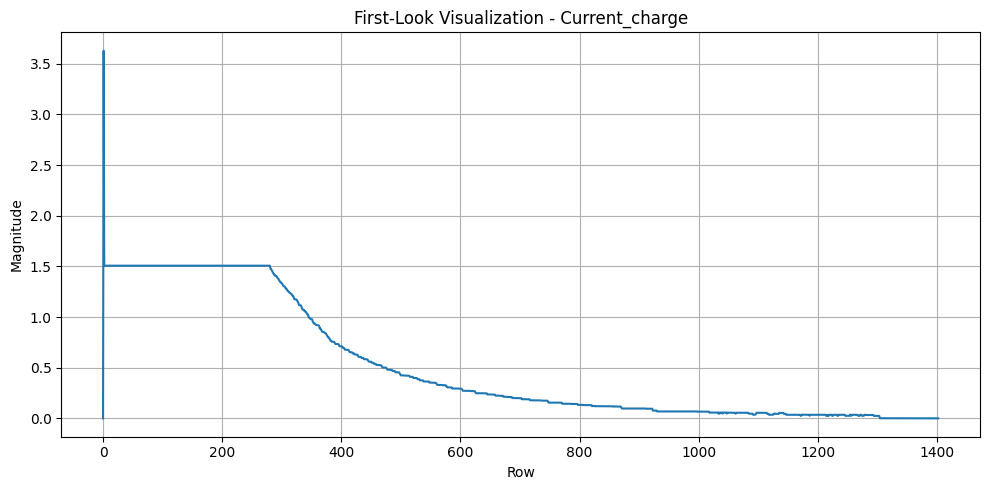

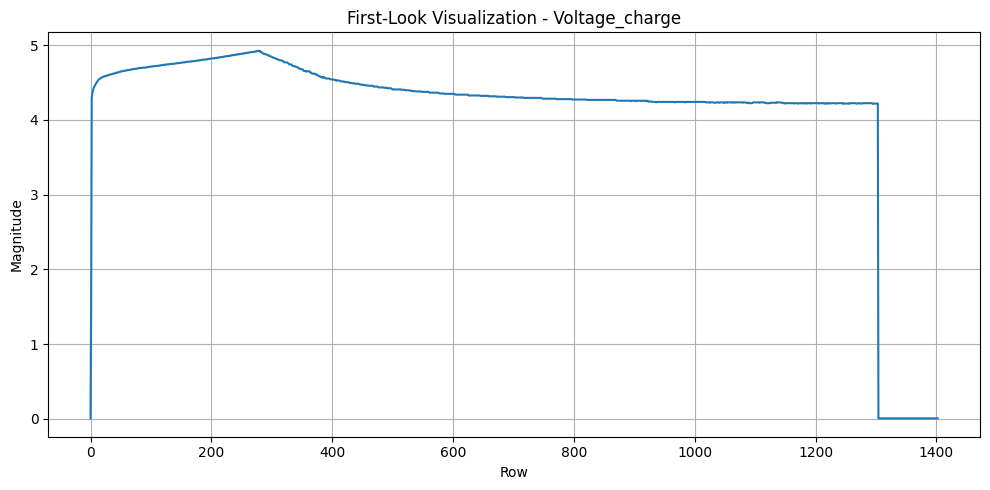

In [12]:
# Day 7 - First-look visualization

import numpy as np
import matplotlib.pyplot as plt

plot_df = sample_df.copy()

# Convert complex-number strings into complex values
for col in plot_df.columns:
    try:
        plot_df[col] = plot_df[col].apply(lambda x: complex(str(x).strip()))
    except:
        pass

# Select complex/numeric columns
plot_columns = []

for col in plot_df.columns:
    if np.iscomplexobj(plot_df[col].values):
        plot_columns.append(col)

print("Columns visualized:")
print(plot_columns)

# Plot each of the first 5 columns individually
for col in plot_columns[:5]:
    magnitude = np.abs(plot_df[col].values)

    plt.figure(figsize=(10, 5))
    plt.plot(magnitude)

    plt.title(f"First-Look Visualization - {col}")
    plt.xlabel("Row")
    plt.ylabel("Magnitude")
    plt.grid(True)

    plt.tight_layout()
    plt.show()